# Grid Search 

In this notebook we will be building an XGBRegressor model using the Grid Search method of hyperparameter turning\. This method involves creating a grid out of the ranges in your suggested hyperparameters\. The code will then try every combination of values within that grid to see which one creates the highest return value\. This method does not involve the model learning from previous run as its only concern is not repeating past combinations of hyperparameter values\. 

### Imports

In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.utils import shuffle

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import math

### Load and Shuffle Data

In [2]:
df = pd.read_csv("housing_cleaned.csv")
df = shuffle(df, random_state=42)

### Split Dataset

In [3]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Baseline Model:

Here we are building a simple baseline unturned XGRegressor model\. This same code appears at the top of most of the note books and is there to locally have a comparison value with the tuned model that is being created below it\. 

In [4]:
baseline = XGBRegressor(
    objective='reg:squarederror', 
    random_state=42,
    n_jobs = -1    
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_rmse = mean_squared_error(y_test, baseline_pred, squared=False)

print("Baseline RMSE (log scale):", baseline_rmse)

Baseline RMSE (log scale): 0.16340095299614865


## Grid Search

### Create the Grid

In [5]:
# Select the possible values for each parameter. This creates the grid from which the tuning will select
# its combinations from. 
param_grid = {
    'n_estimators': [400, 500, 600],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.03, 0.05, 0.07],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5]
}

### Set Up the Grid Search

In [6]:
# Create basic model
xgb = XGBRegressor(
    objective = 'reg:squarederror',
    random_state = 42,
    n_jobs = 1
)

In [7]:
# Create the Grid Search element
grid_search = GridSearchCV(
    estimator = xgb,
    param_grid = param_grid,
    scoring = 'neg_mean_squared_error',
    cv = 5,
    verbose = 2,
    n_jobs = 1 
)

### Fit the Model

Here we are going to fit our new Grid Search model to the training data\. While doing this we will be timing how long this process takes\. The purpose of this is to give us a realitive comparison value when looking at the other model that use different tuning methods\. 

In [8]:
start = time.time()

In [9]:
grid_search.fit(X_train, y_train)

[CV] END colsample_bytree=0.7, learning_rate=0.07, max_depth=5, min_child_weight=5, n_estimators=600, subsample=0.7; total time=   1.4s
[CV] END colsample_bytree=0.7, learning_rate=0.07, max_depth=5, min_child_weight=5, n_estimators=600, subsample=0.7; total time=   1.5s
[CV] END colsample_bytree=0.7, learning_rate=0.07, max_depth=5, min_child_weight=5, n_estimators=600, subsample=0.7; total time=   1.5s
[CV] END colsample_bytree=0.7, learning_rate=0.07, max_depth=5, min_child_weight=5, n_estimators=600, subsample=0.7; total time=   1.5s
[CV] END colsample_bytree=0.7, learning_rate=0.07, max_depth=5, min_child_weight=5, n_estimators=600, subsample=0.8; total time=   1.4s
[CV] END colsample_bytree=0.7, learning_rate=0.07, max_depth=5, min_child_weight=5, n_estimators=600, subsample=0.8; total time=   1.4s
[CV] END colsample_bytree=0.7, learning_rate=0.07, max_depth=5, min_child_weight=5, n_estimators=600, subsample=0.8; total time=   1.4s
[CV] END colsample_bytree=0.7, learning_rate=0.0

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=1, num_parallel_tree=None, ...),
             n_jobs=1,
             param_grid={'colsample_bytree': [0.6, 0.7, 0.8],
                         'learning_rate': [0.03, 0.05, 0.07],
                         'max_depth': [5, 6, 7], 'min_child_weight': [1, 3, 5],
                         'n_estimators': [400, 500, 600],
                         'subsample': [0.7, 0.8]},
             scoring='neg_mean_squared_error', verbose=2)

In [10]:
end = time.time()

print(f"Total time: {(end - start)/60:.2f} minutes")

Total time: 81.88 minutes


### Extract Best Hyperparameter Values from Tuning

Now that we are finish tuning this model we can extract what the best combination of values the grid\_search was able to locate\. This does not mean that we are finished\. We now have to use these value in the creation of our final model\.

In [11]:
best_params = grid_search.best_params_

print('Best Params:')
print(best_params)

Best Params:
{'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 600, 'subsample': 0.8}


### Create Model Using Best Parameters

Its time to create our final model using the parameters that our tuning just found\. We will start the process with another data split, but this time the result will be us creating a validation dataset\. 

In [12]:
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [13]:
# Starting by creating the new model with the Best Parameters
best_model = XGBRegressor(
    **best_params,
    objective = 'reg:squarederror',
    random_state = 42,
    early_stopping_rounds = 20 
)

# Fitting the model, but this time without a tuning method involved and adding validation.
best_model.fit(
    X_train2,
    y_train2,
    eval_set=[(X_train2, y_train2), (X_val, y_val)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=20,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=None, num_parallel_tree=None, ...)

### Results

In [14]:
# Run a prediction on the final model and evaluate the results to determine the model's Root Mean Square Error.
y_pred = best_model.predict(X_test)
rmse_log = mean_squared_error(y_test, y_pred, squared = False)
print('Test RMSE (log scale):', rmse_log)

Test RMSE (log scale): 0.15898648431164503


In [15]:
# Convert Log RMSE to something easier to interpert.
print(math.exp(rmse_log))

1.1723221018334609


### Visualize the Results

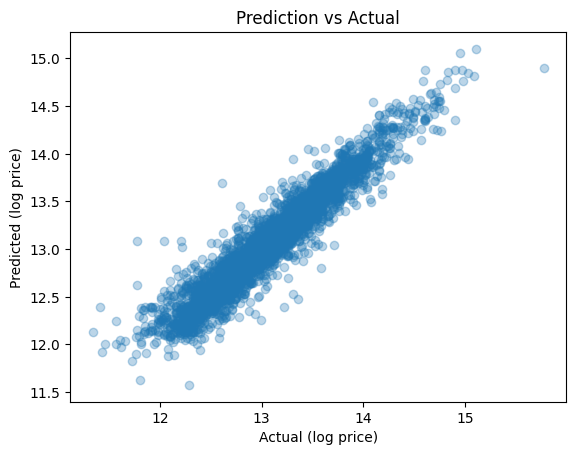

In [16]:
plt.figure()
plt.scatter(y_test, y_pred, alpha = 0.3)
plt.xlabel("Actual (log price)")
plt.ylabel("Predicted (log price)")
plt.title("Prediction vs Actual")
plt.show()

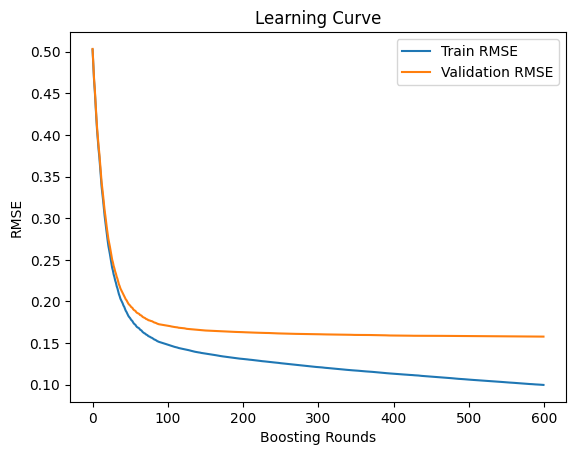

In [17]:
results = best_model.evals_result()

train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

plt.figure()
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse, label='Validation RMSE')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('Learning Curve')
plt.legend()
plt.show()

Since the Validation curve is above the training curve the model is not overfitting\. As far as underfittings, the end of the graph show as different between the lines of rougly and RMSE of 0\.05\. This is a small value, so we can determine this model is not underfitting\. 

### How Important is Each Variable

In [18]:
importance = best_model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    'feature' : features,
    'importance': importance
}).sort_values(by = 'importance', ascending = False)

print(imp_df.head(10))

          feature  importance
8           grade    0.202035
12            lat    0.094949
2     sqft_living    0.085978
20  zipcode_98004    0.053958
5      waterfront    0.042131
30  zipcode_98023    0.040292
6            view    0.030778
18  zipcode_98002    0.023457
41  zipcode_98039    0.022345
42  zipcode_98040    0.016239


### Best Round

In [19]:
print(best_model.best_iteration)

596


In [20]:
best_round = np.argmin(val_rmse)
print("Best round from curve:", best_round)

Best round from curve: 596


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=89799500-4443-401d-b5a6-3a6742d3b89e' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>